# Classification of Dementia type from FDG-PET images: old-school strategy

In this notebook we will show how to classify PET images in dementia or healthy, and the subtype of dementia using a very simple strategy:
estimating the spatial pattern and computing its expression

These PET images are saved in the nifti file format. Start by learning how to read them using nibabel

In [2]:
import nibabel as nib
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# Task 1: read one Nifti file

you will real the file using nib.load, which returns a structure. nifiti files either have .nii extension or (older legacy format, two files per images *.hdr and *.img )
From its headers, assuming it returns foo you can get
1. the image matrix size by calling foo.header.get_data_shape()
2. The pixel size by doing foo.header.get_zooms()
3. The storage data type foo.header.get_data_dtype()
4. Then the image matrix gets returned by foo.get_fdata(), which accepts a data e.g. type foo.get_fdata(dtype=np.float32)

Load one nifti file and display some slices.

Also Display the colorbar: what intensity values are you expecting?


In [3]:
nibTest = nib.load('D:/dati_corso/Dementia_PET/AD/swSPIM72_A_MBqcc_f.hdr')

In [4]:
nibTest.header.get_zooms()

(2.0, 2.0, 2.0)

## Task 1.1: Read all the files

Use glob to make a list of all the files for all the categories.

All the images have been spatially normalized, so they're supposed to have the same matrix shape and the same pixel size. Check this.

Read all the images and store them in numpy vectors

Read also the mask image. (masks/explicit_mask.nii)

Superimpose one (randomly chosen) image with the mask contour on 3 planes.

In [5]:
baseDir = 'D://dati_corso/Dementia_PET'
adPETL = glob.glob(os.path.join(baseDir,'AD','*.hdr'))
adPETL += glob.glob(os.path.join(baseDir,'AD','*.nii'))

bvPETL = glob.glob(os.path.join(baseDir,'bvFTD','*.hdr'))
bvPETL += glob.glob(os.path.join(baseDir,'bvFTD','*.nii'))

DLBPETL = glob.glob(os.path.join(baseDir,'DLB','*.hdr'))
DLBPETL += glob.glob(os.path.join(baseDir,'DLB','*.nii'))

hcPETL = glob.glob(os.path.join(baseDir,'HC','*.hdr'))

In [6]:
print(len(adPETL))
print(len(bvPETL))
print(len(DLBPETL))
print(len(hcPETL))

30
32
34
112


Read all the images and store them in numpy vectors

Read also the mask image.

Superimpose one (randomly chosen) image with the mask contour on 3 planes.

In [7]:
immDim = nib.load(adPETL[0]).get_fdata().shape
hcImmVect = np.zeros(immDim+(len(hcPETL),),dtype=np.float32)
adImmVect = np.zeros(immDim+(len(adPETL),),dtype=np.float32)
bvImmVect = np.zeros(immDim+(len(bvPETL),),dtype=np.float32)
dlbImmVect = np.zeros(immDim+(len(DLBPETL),),dtype=np.float32)

In [8]:
maskHead = nib.load(os.path.join(baseDir,'masks','explicit_mask.nii'))
maskImm = maskHead.get_fdata(dtype=np.float32)>0.5

In [9]:
for pIdx,adSub in enumerate(adPETL):
    adImmVect[:,:,:,pIdx] = nib.load(adSub).get_fdata(dtype=np.float32)
for pIdx,hcSub in enumerate(hcPETL):
    hcImmVect[:,:,:,pIdx] = nib.load(hcSub).get_fdata(dtype=np.float32)    
for pIdx,bvSub in enumerate(bvPETL):
    bvImmVect[:,:,:,pIdx] = nib.load(bvSub).get_fdata(dtype=np.float32)
for pIdx,dlbSub in enumerate(DLBPETL):   
    dlbImmVect[:,:,:,pIdx] = nib.load(dlbSub).get_fdata(dtype=np.float32)    

# Task 2: prepare for analysis
### Normalize image intensities

PET images are in units of tracer concentration which do not have a direct biological meaning

To be able to estimate them, we need to scale the activity to some reference value. We can do this in multiple ways: either using a reference region (known from biological knowledge not to be affected by a pathology of interest) or the "global mean".


In [10]:
def normImm (immVect,mask):
    
    for pIdx in range(immVect.shape[-1]):       
        tempImm = immVect[:,:,:,pIdx]        
        immVect[:,:,:,pIdx] = tempImm/np.nanmean(tempImm[mask])
    return immVect

In [11]:
hcImmVect = normImm(hcImmVect,maskImm)
adImmVect = normImm(adImmVect,maskImm)
bvImmVect = normImm(bvImmVect,maskImm)
dlbImmVect = normImm(dlbImmVect,maskImm)
    

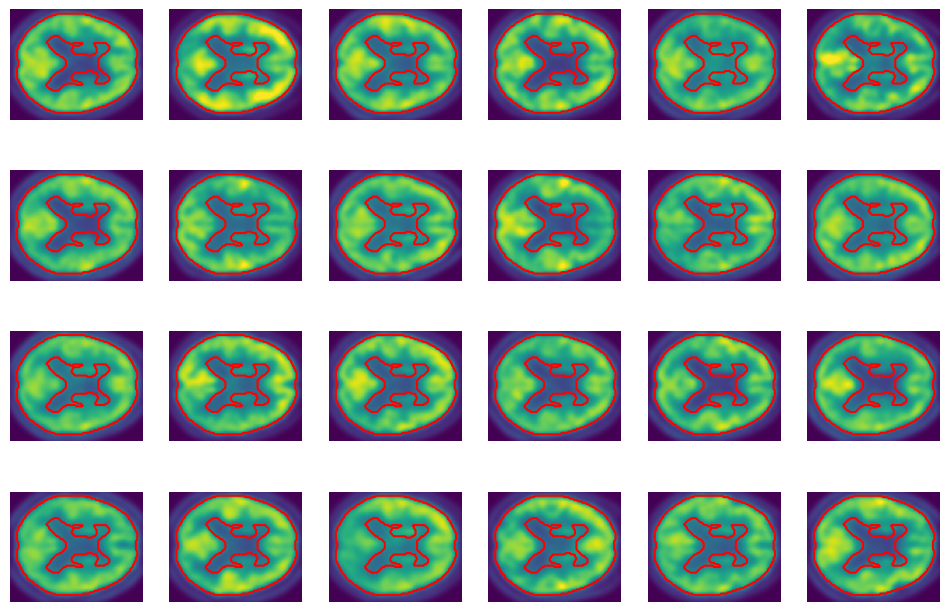

In [12]:
plt.figure(figsize=(12,8))
for i in range(24):
    plt.subplot(4,6,i+1)
    plt.imshow(dlbImmVect[:,:,35,i],vmin=0,vmax=1.5)
    plt.contour(maskImm[:,:,35],[0.5],colors='r')
    plt.axis('off')

# Task 3: Do a t-test of the images

Compare the images pixel by pixel for every pathology compared to the HC group


In [ ]:
nAD = adImmVect.shape[-1]
nHC = hcImmVect.shape[-1]
num = np.mean(adImmVect,axis=-1) - np.mean(hcImmVect,axis=-1)
den = np.sqrt(
    ((nAD-1)*np.std(adImmVect, axis=-1)**2
     + (nHC-1)*np.std(hcImmVect, axis=-1)**2)
    / (nAD + nHC - 1)
)

tTestAD = (num/den)*maskImm

### T-test of AD overlaid on an average brain

(-0.5, 78.5, 94.5, -0.5)

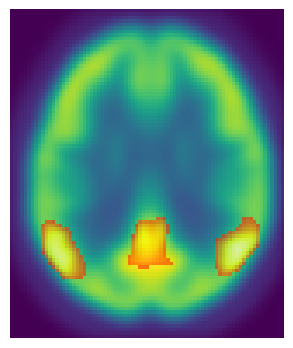

In [14]:
plt.figure(figsize=(12,8))
plt.subplot(131)
slIdx = 37
plt.imshow(np.flip(np.mean(hcImmVect,axis=-1)[:,:,slIdx].T))
tMap = -np.flip((tTestAD)[:,:,slIdx].T)
tMap[tMap<1.65]=np.nan
plt.imshow(tMap,vmin=0,vmax=4,cmap='hot',alpha=.6)#,vmax=-1.7)
plt.axis('off')
#plt.colorbar()

## Compute the "pathology patterns"

We define the average pattern of a pathology the difference between the average healthy control image and the average pathological image

In the following blocks we will show the mean patterns and save the files to disk

### Save to file

# Task 3: Compute the "pattern expression"

We define the expression of a pattern as the projection (in the vector algebra meaning) of a patient image on the reference pattern

In [15]:
hcMean = np.mean(hcImmVect,axis=-1)
adMean = np.mean(adImmVect,axis=-1)
bvMean = np.mean(bvImmVect,axis=-1)
dlbMean = np.mean(dlbImmVect,axis=-1)
adPattern = -adMean+hcMean
bvPattern = -bvMean+hcMean
dlbPattern = -dlbMean+hcMean

(-0.5, 78.5, 94.5, -0.5)

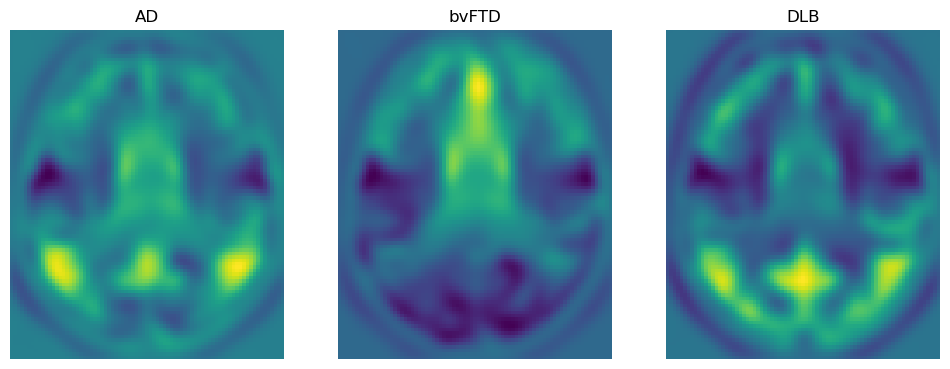

In [16]:
plt.figure(figsize=(12,8))
plt.subplot(131)
plt.imshow(np.flip((adPattern)[:,:,35].T))
plt.title('AD')
plt.axis('off')
plt.subplot(132)
plt.imshow(np.flip((bvPattern)[:,:,35].T))
plt.axis('off')
plt.title('bvFTD')
plt.subplot(133)
plt.title('DLB')
plt.imshow(np.flip((dlbPattern)[:,:,35].T))
plt.axis('off')

In [17]:
headEx = nib.load(adSub)
adPatternNifti = nib.Nifti1Image(adPattern, headEx.affine, headEx.header)
nib.save(adPatternNifti,os.path.join(baseDir,'patterns','AD_pattern.nii'))
dlbPatternNifti = nib.Nifti1Image(bvPattern, headEx.affine, headEx.header)
nib.save(dlbPatternNifti,os.path.join(baseDir,'patterns','DLB_pattern.nii'))
bvFTDPatternNifti = nib.Nifti1Image(dlbPattern, headEx.affine, headEx.header)
nib.save(bvFTDPatternNifti,os.path.join(baseDir,'patterns','bvFTD_pattern.nii'))

### Show the histograms of the scores

In [18]:
def computeProjections(patImmVect,hcMean,patternList):
    patternExp = np.zeros((patImmVect.shape[-1],len(patternList)))
    for pIdx in range(patImmVect.shape[-1]):
        pDiff = patImmVect[:,:,:,pIdx]-hcMean
        for patternIdx,pattern in enumerate(patternList):
            pExp = np.matmul(pDiff.flatten().T,pattern.flatten())
            patternExp[pIdx,patternIdx] = pExp
    return patternExp

In [19]:
adScores = computeProjections(adImmVect,hcMean,[adPattern,dlbPattern,bvPattern])
hcScores = computeProjections(hcImmVect,hcMean,[adPattern,dlbPattern,bvPattern])
dlbScores = computeProjections(dlbImmVect,hcMean,[adPattern,dlbPattern,bvPattern])
bvScores = computeProjections(bvImmVect,hcMean,[adPattern,dlbPattern,bvPattern])

scoresList = [adScores,hcScores,dlbScores,bvScores]
labelsList = ['AD','HC','DLB','bvFTD']


In [20]:
scoresList[3].shape

(32, 3)

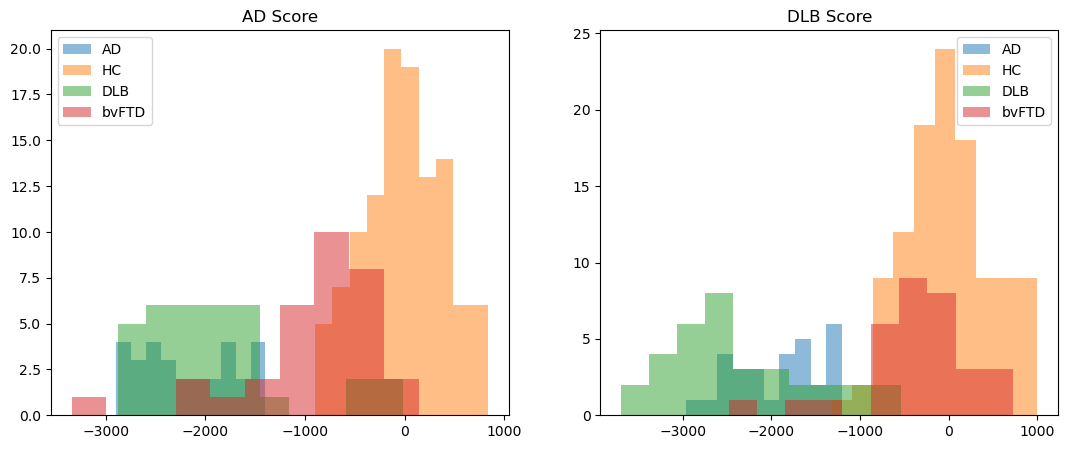

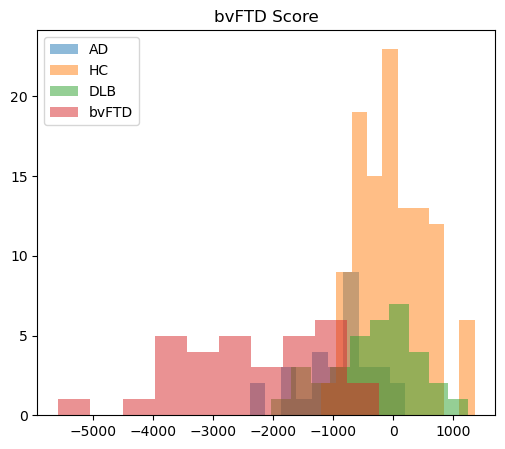

In [21]:
plt.figure(figsize=(13,5))
plt.subplot(121)
for score in scoresList:
    plt.hist(score[:,0],alpha=0.5)
plt.legend(labelsList)
plt.title('AD Score')
plt.subplot(122)
for score in scoresList:
    plt.hist(score[:,1],alpha=0.5)
plt.legend(labelsList)
plt.title('DLB Score')

plt.figure(figsize=(13,5))
plt.subplot(121)
for score in scoresList:
    plt.hist(score[:,2],alpha=0.5)
plt.legend(labelsList)
_=plt.title('bvFTD Score')

### Compute the effect size of the scores for the comparison of each pathology against healthy controls

In [22]:
print('\t AD Score\n')
scoreIdx = 0
for scIdx,score in enumerate(scoresList):
    if scIdx==1:
        continue
    meanHC = np.mean(scoresList[1][:,scoreIdx])
    stdHC = np.std(scoresList[1][:,scoreIdx])
    meanPat = np.mean(score[:,scoreIdx])
    stdPat = np.std(score[:,scoreIdx])
    n1 = scoresList[1].shape[0]
    n2 = score.shape[0]
    pooledSTD = np.sqrt(((n1-1)*stdHC**2+(n2-1)*stdPat**2)/(n1+n2-2))
    print('Cohen D for ' +labelsList[scIdx] + ' vs HC= ' + str(round((-meanPat+meanHC)/pooledSTD,1)))

print('\n\t DLB Score\n')
scoreIdx = 1
for scIdx,score in enumerate(scoresList):
    if scIdx==1:
        continue
    meanHC = np.mean(scoresList[1][:,scoreIdx])
    stdHC = np.std(scoresList[1][:,scoreIdx])
    meanPat = np.mean(score[:,scoreIdx])
    stdPat = np.std(score[:,scoreIdx])
    n1 = scoresList[1].shape[0]
    n2 = score.shape[0]
    pooledSTD = np.sqrt(((n1-1)*stdHC**2+(n2-1)*stdPat**2)/(n1+n2-2))
    print('Cohen D for ' +labelsList[scIdx] + ' vs HC= ' + str(round((-meanPat+meanHC)/pooledSTD,1)))    
    
    
print('\n\t bvFTD Score\n')
scoreIdx = 2
for scIdx,score in enumerate(scoresList):
    if scIdx==1:
        continue
    meanHC = np.mean(scoresList[1][:,scoreIdx])
    stdHC = np.std(scoresList[1][:,scoreIdx])
    meanPat = np.mean(score[:,scoreIdx])
    stdPat = np.std(score[:,scoreIdx])
    n1 = scoresList[1].shape[0]
    n2 = score.shape[0]
    pooledSTD = np.sqrt(((n1-1)*stdHC**2+(n2-1)*stdPat**2)/(n1+n2-2))
    print('Cohen D for ' +labelsList[scIdx] + ' vs HC= ' + str(round((-meanPat+meanHC)/pooledSTD,1)))    

	 AD Score

Cohen D for AD vs HC= 5.3
Cohen D for DLB vs HC= 3.9
Cohen D for bvFTD vs HC= 1.9

	 DLB Score

Cohen D for AD vs HC= 3.9
Cohen D for DLB vs HC= 4.2
Cohen D for bvFTD vs HC= 0.7

	 bvFTD Score

Cohen D for AD vs HC= 1.6
Cohen D for DLB vs HC= 0.6
Cohen D for bvFTD vs HC= 3.2


### Show the scatter plot of each score against each other

Some scores are correlated

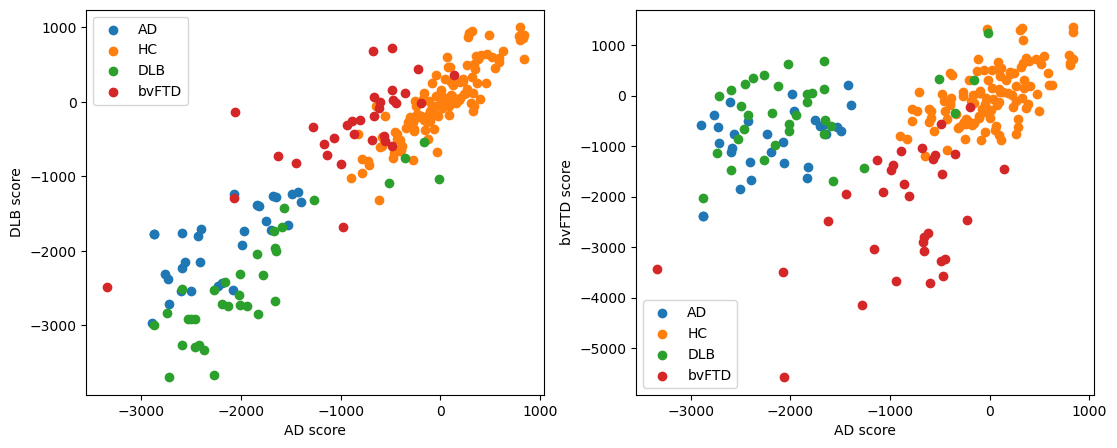

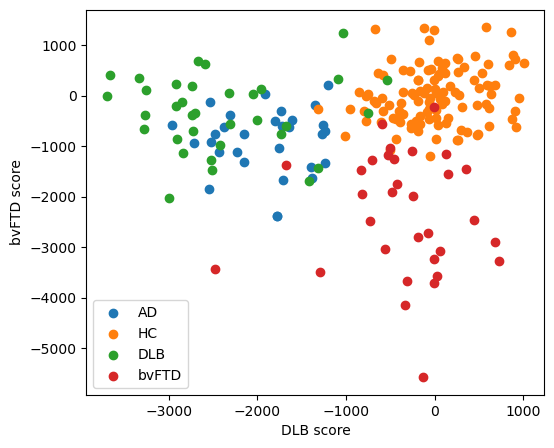

In [23]:
plt.figure(figsize=(13,5))
plt.subplot(121)
for score in scoresList:
    plt.scatter(score[:,0],score[:,1])
plt.xlabel('AD score')
plt.ylabel('DLB score')
plt.legend(labelsList)

plt.subplot(122)
for score in scoresList:
    plt.scatter(score[:,0],score[:,2])
plt.xlabel('AD score')
plt.ylabel('bvFTD score')    
plt.legend(labelsList)

plt.figure(figsize=(13,5))
plt.subplot(121)
for score in scoresList:
    plt.scatter(score[:,1],score[:,2])
plt.xlabel('DLB score')
plt.ylabel('bvFTD score')
plt.legend(labelsList)

# Task 4: Implement a classifier to perform the actual classification from these scores

In [24]:
from sklearn.ensemble import RandomForestClassifier
RFC = RandomForestClassifier(n_estimators=100,max_depth=3,class_weight='balanced')

In [25]:
scoreVect = np.concatenate(scoresList)
labVect = np.concatenate([np.zeros((scoresList[0].shape[0],)),
                         np.ones((scoresList[1].shape[0],)),
                         2*np.ones((scoresList[2].shape[0],)),
                         3*np.ones((scoresList[3].shape[0],))])

In [26]:
RFC.fit(scoreVect,labVect)

RandomForestClassifier(class_weight='balanced', max_depth=3)

In [27]:
RFC.score(scoreVect,labVect)

0.9134615384615384

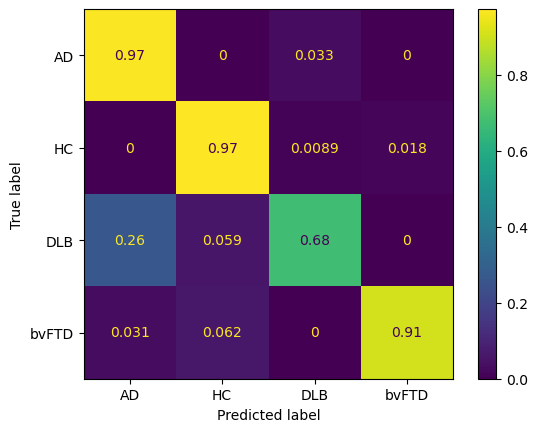

In [28]:
from  sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(RFC,
                                     scoreVect,
                                     labVect,
                                     display_labels=labelsList,
                                     normalize='true')

# Task 5: Try other classification strategies.
E.g.: try applying a PCA to the original images (After intensity scaling)
Or... PCA on log-transformed images without any scaling?? (can this be done?)



In [29]:
from sklearn.decomposition import PCA
allImm = np.concatenate((adImmVect,hcImmVect,dlbImmVect,bvImmVect),axis=-1)
pca = PCA(n_components=20)


In [30]:
allImmM = allImm[maskImm]
pca.fit(allImmM.T)

PCA(n_components=20)

Text(0.5, 1.0, 'Explained Variance')

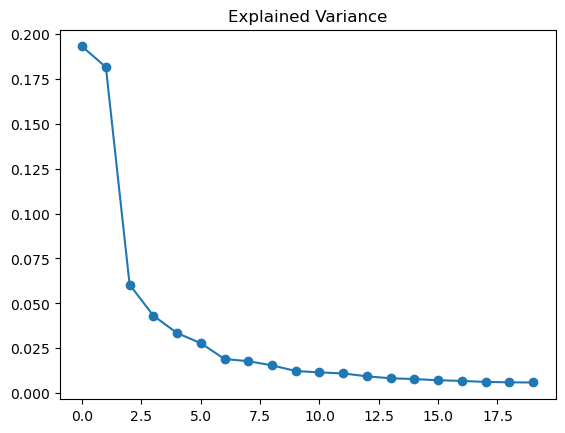

In [31]:
plt.plot(pca.explained_variance_ratio_,'o-')
plt.title('Explained Variance')

Text(0.5, 1.0, 'Cumulative expl. Variance')

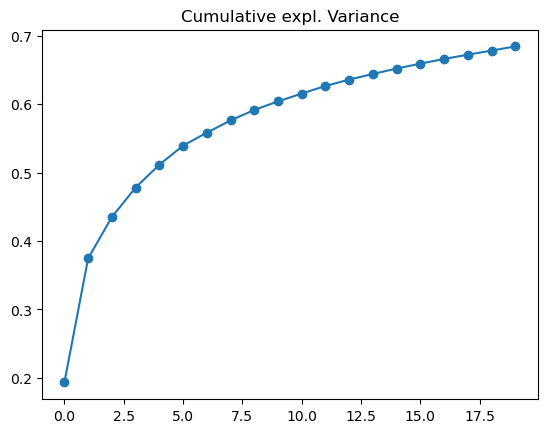

In [32]:
plt.plot(np.cumsum(pca.explained_variance_ratio_),'o-')
plt.title('Cumulative expl. Variance')

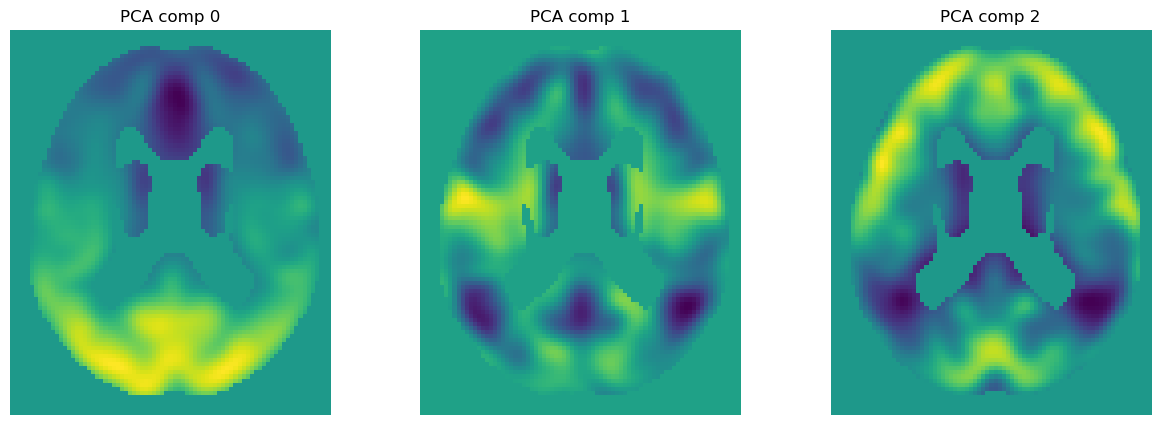

In [33]:
plt.figure(figsize=(15,5))
for cIdx in range(3):
    plt.subplot(1,3,cIdx+1)
    i1 = np.zeros(maskImm.shape)
    i1[maskImm]=pca.components_[cIdx,:]
    plt.imshow(np.flip(i1[:,:,35].T))
    plt.axis('off')
    plt.title(f'PCA comp {cIdx}')

In [34]:
pcaScores = pca.transform(allImmM.T)



In [35]:
pcaScores.shape,labT.shape

NameError: name 'labT' is not defined

In [ ]:
labelsList[np.uint(labI)]

'bvFTD'

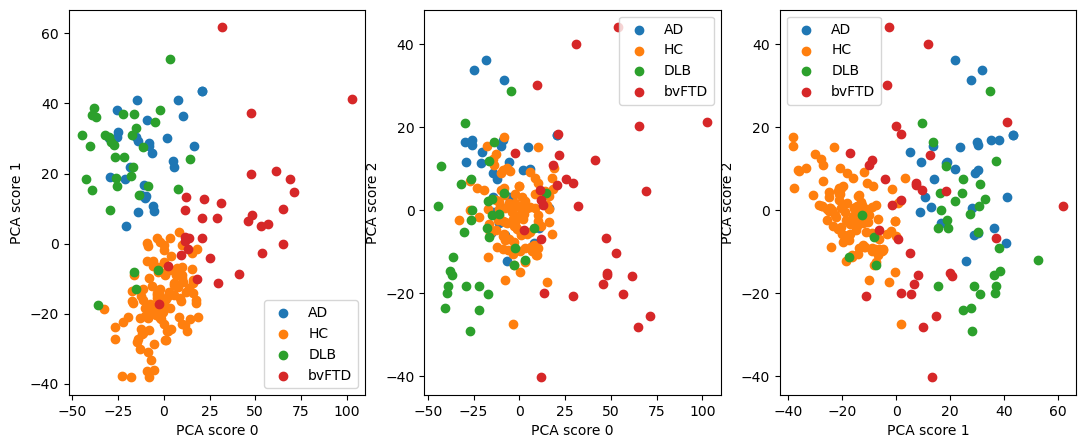

In [ ]:
plt.figure(figsize=(13,5))
plt.subplot(131)
for labI in np.unique(labVect):
    labT = labVect==labI
    plt.scatter(pcaScores[labT,0],pcaScores[labT,1],label=labelsList[np.uint(labI)])
plt.xlabel('PCA score 0')
plt.ylabel('PCA score 1')
plt.legend()

plt.subplot(132)
for labI in np.unique(labVect):
    labT = labVect==labI
    plt.scatter(pcaScores[labT,0],pcaScores[labT,2],label=labelsList[np.uint(labI)])
plt.xlabel('PCA score 0')
plt.ylabel('PCA score 2')
plt.legend()

plt.subplot(133)
for labI in np.unique(labVect):
    labT = labVect==labI
    plt.scatter(pcaScores[labT,1],pcaScores[labT,2],label=labelsList[np.uint(labI)])
plt.xlabel('PCA score 1')
plt.ylabel('PCA score 2')
plt.legend()


# Apply to test data

In [36]:
hcTest = glob.glob(os.path.join('d:\\dati_corso\\Dementia_PET\\testData\\HC','*.nii'))
adTest = glob.glob(os.path.join('d:\\dati_corso\\Dementia_PET\\testData\\AD','*.nii'))

In [39]:
adTestVect = np.zeros(adImmVect.shape[:3]+(len(adTest),),dtype=np.float32)
hcTestVect = np.zeros(hcImmVect.shape[:3]+(len(hcTest),),dtype=np.float32)
for pIdx,sub in enumerate(hcTest):
    hcTestVect[:,:,:,pIdx] = nib.load(sub).get_fdata(dtype=np.float32)
for pIdx,sub in enumerate(adTest):
    adTestVect[:,:,:,pIdx] = nib.load(sub).get_fdata(dtype=np.float32)

In [41]:
hcTestVect = normImm(hcTestVect,maskImm)
adTestVect = normImm(adTestVect,maskImm)

In [42]:
hcMasked = hcTestVect[maskImm]
adMasked = adTestVect[maskImm]

In [45]:
hcTestScores = pca.transform(hcMasked.T)
adTestScores = pca.transform(adMasked.T)

In [51]:
hcTestScores.shape

(14, 20)

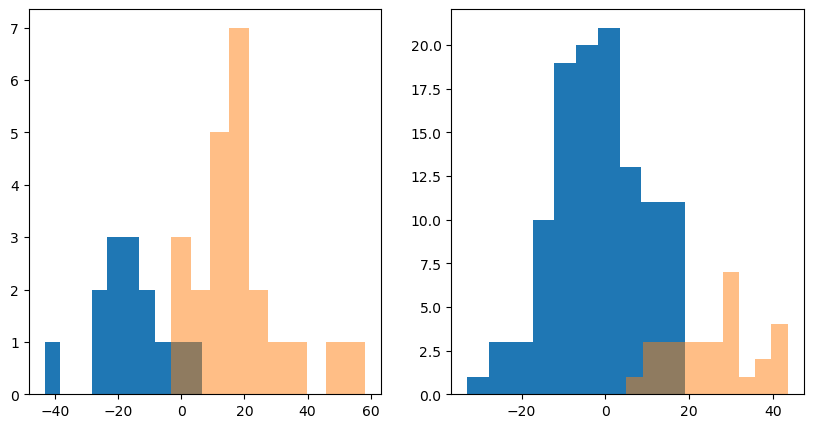

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(121)
_ = plt.hist(hcTestScores[:,0],10)
_ = plt.hist(adTestScores[:,0],10,alpha=.5)
plt.subplot(122)
labT = labVect==1
_ = plt.hist(pcaScores[labT,0],10)
labT = labVect==0
_ = plt.hist(pcaScores[labT,0],10,alpha=.5)
